[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sarma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sarma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sarma\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\sarma\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Dataset Shape: (4999, 6)
medical_specialty
Surgery                       1088
Consult - History and Phy.     516
Cardiovascular / Pulmonary     371
Orthopedic                     355
Name: count, dtype: int64

Example Clean Text:
3     left atrial enlargement left atrial diameter c...
4     left ventricular cavity size wall thickness ap...
7     echocardiogram multiple view heart great vesse...
9     normal cardiac chamber size normal left ventri...
11    study mild aortic stenosis widely calcified mi...
Name: clean_text, dtype: object

Extracted Nouns: ['enlargement', 'diameter', 'cm', 'size', 'right', 'ventricle', 'function', 'ejection', 'fraction', 'function']
Extracted Adjectives: ['atrial', 'atrial', 'normal', 'normal', 'lv', 'systolic', 'ventricular', 'normal', 'lv', 'diastolic']

Cardiology Records: 371


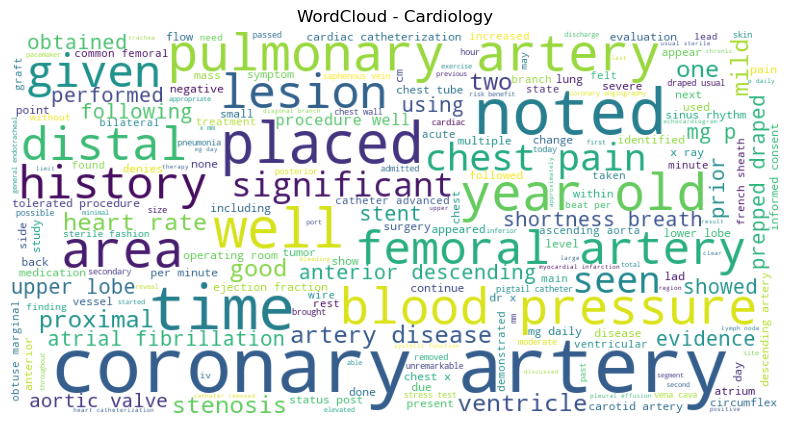

Orthopedic Records: 355


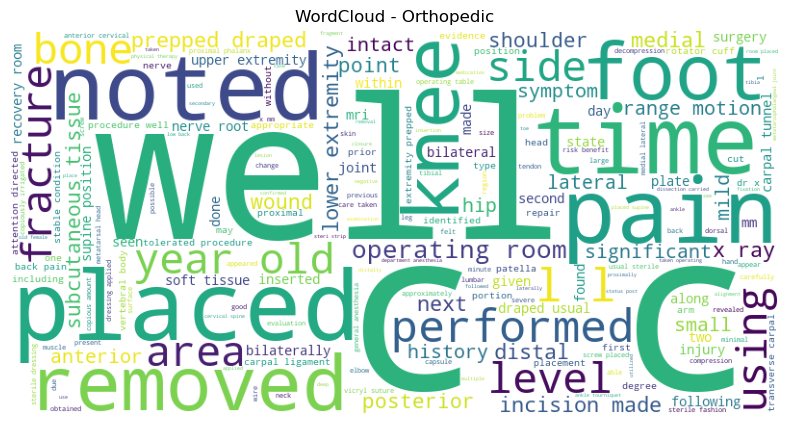


Negation Example:
{'Entity': 'pain', 'Status': 'Present'}

Model Accuracy: 0.6051502145922747


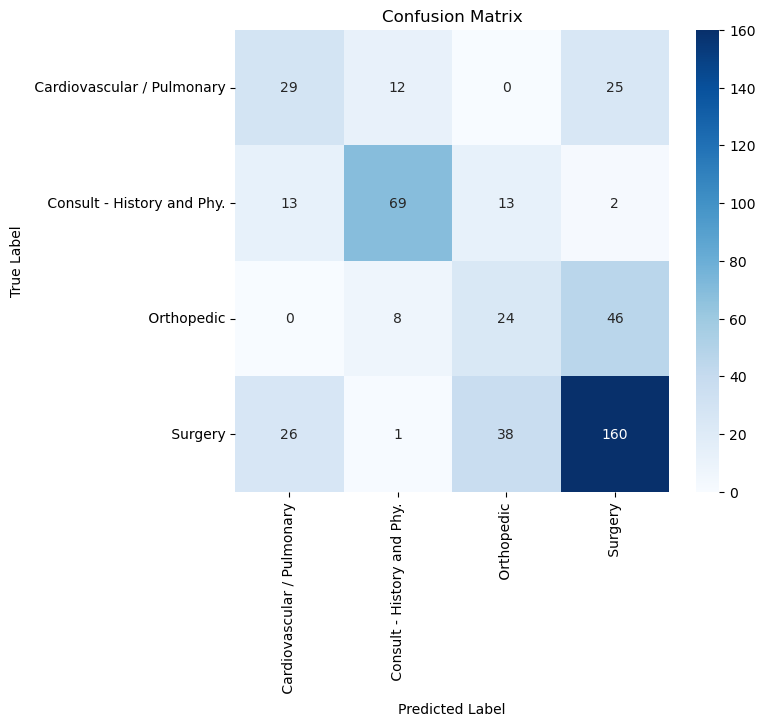

In [10]:
# ============================================================
# MEDICAL NLP PROJECT
# PHASE 1 → PHASE 4 COMPLETE PIPELINE
# ============================================================


# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import re
import nltk
import spacy

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk import pos_tag

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix

from wordcloud import WordCloud, STOPWORDS

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# DOWNLOAD REQUIRED NLTK DATA
# ============================================================

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')


# ============================================================
# LOAD SPACY MODEL
# ============================================================

nlp = spacy.load("en_core_web_sm")


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("mtsamples.csv")

print("Dataset Shape:", df.shape)

df = df[['transcription','medical_specialty']]

df = df.dropna()


# ============================================================
# SELECT TOP SPECIALTIES
# ============================================================

top_specialties = df['medical_specialty'].value_counts().head(4).index

df = df[df['medical_specialty'].isin(top_specialties)]

print(df['medical_specialty'].value_counts())


# ============================================================
# PHASE 1 : CLINICAL PREPROCESSING
# ============================================================


# ------------------------------------------------------------
# DELIVERABLE : PREPROCESSING
# REGEX used to remove headers
# ------------------------------------------------------------

def remove_headers(text):

    text = re.sub(r'[A-Z\s]+:', ' ', text)

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    return text


# ------------------------------------------------------------
# ABBREVIATION EXPANSION
# ------------------------------------------------------------

abbrev_dict = {

    "pt":"patient",
    "hx":"history",
    "dx":"diagnosis",
    "tx":"treatment",
    "sx":"symptoms"
}


def expand_abbreviations(text):

    words = text.split()

    expanded = []

    for word in words:

        if word.lower() in abbrev_dict:

            expanded.append(abbrev_dict[word.lower()])

        else:

            expanded.append(word)

    return " ".join(expanded)



# ------------------------------------------------------------
# TOKENIZATION + LEMMATIZATION
# ------------------------------------------------------------

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()


def preprocess_text(text):

    text = remove_headers(text)

    text = expand_abbreviations(text)

    tokens = word_tokenize(text.lower())

    clean_words = []

    for word in tokens:

        if word not in stop_words:

            lemma = lemmatizer.lemmatize(word)

            clean_words.append(lemma)

    return " ".join(clean_words)



df['clean_text'] = df['transcription'].apply(preprocess_text)

print("\nExample Clean Text:")

print(df['clean_text'].head())


# ============================================================
# PHASE 2 : ENTITY EXTRACTION USING POS TAGGING
# ============================================================

def extract_entities(text):

    tokens = word_tokenize(text)

    tags = pos_tag(tokens)

    nouns = []

    adjectives = []

    for word, tag in tags:

        if tag in ['NN','NNS']:

            nouns.append(word)

        if tag == 'JJ':

            adjectives.append(word)

    return nouns, adjectives


sample = df['clean_text'].iloc[0]

nouns, adjectives = extract_entities(sample)

print("\nExtracted Nouns:", nouns[:10])

print("Extracted Adjectives:", adjectives[:10])


# ============================================================
# WORD CLOUD VISUALIZATION
# CARDIOLOGY VS ORTHOPEDIC
# ============================================================

wc_stopwords = set(STOPWORDS)

wc_stopwords.update(["patient","normal","left","right"])



# CARDIOLOGY DATA

cardio_df = df[df['medical_specialty'].str.contains("Cardio", case=False)]

print("\nCardiology Records:", len(cardio_df))


if len(cardio_df) > 0:

    cardio_text = " ".join(cardio_df['clean_text'])

    wc1 = WordCloud(

        width=800,
        height=400,
        background_color='white',
        stopwords=wc_stopwords

    ).generate(cardio_text)

    plt.figure(figsize=(10,5))

    plt.imshow(wc1)

    plt.axis("off")

    plt.title("WordCloud - Cardiology")

    plt.show()

else:

    print("No Cardiology data found.")



# ORTHOPEDIC DATA

ortho_df = df[df['medical_specialty'].str.contains("Ortho", case=False)]

print("Orthopedic Records:", len(ortho_df))


if len(ortho_df) > 0:

    ortho_text = " ".join(ortho_df['clean_text'])

    wc2 = WordCloud(

        width=800,
        height=400,
        background_color='white',
        stopwords=wc_stopwords

    ).generate(ortho_text)

    plt.figure(figsize=(10,5))

    plt.imshow(wc2)

    plt.axis("off")

    plt.title("WordCloud - Orthopedic")

    plt.show()

else:

    print("No Orthopedic data found.")



# ============================================================
# PHASE 3 : NEGATION DETECTION
# ============================================================

# DELIVERABLE : NEGATION LOGIC

def detect_negation(sentence, entity):

    doc = nlp(sentence)

    neg_words = ["no","not","denies","without"]

    for token in doc:

        if token.text.lower() == entity.lower():

            for child in token.children:

                if child.text.lower() in neg_words:

                    return {"Entity":entity,"Status":"Negated"}

            if token.i > 0 and doc[token.i-1].text.lower() in neg_words:

                return {"Entity":entity,"Status":"Negated"}

    return {"Entity":entity,"Status":"Present"}



sentence = "Patient denies chest pain"

print("\nNegation Example:")

print(detect_negation(sentence,"pain"))



# ============================================================
# PHASE 4 : SPECIALTY CLASSIFICATION
# ============================================================

# DELIVERABLE : CLASSIFIER PIPELINE

vectorizer = TfidfVectorizer(

    max_features=8000,
    ngram_range=(1,2)

)

X = vectorizer.fit_transform(df['clean_text'])

y = df['medical_specialty']


# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)


# TRAIN MODEL

model = LinearSVC()

model.fit(X_train, y_train)


# PREDICTION

y_pred = model.predict(X_test)


# MODEL ACCURACY

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)



# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_

)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()